In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from helpers import *

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
DATASET_DIR = "../planetsdataset"

In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [4]:
train_dataset, valid_dataset, test_dataset, class_names = load_datasets(DATASET_DIR, IMG_SIZE, BATCH_SIZE)

Found 2430 files belonging to 12 classes.
Found 666 files belonging to 12 classes.
Found 341 files belonging to 12 classes.


In [14]:
class_names

['asteroid',
 'earth',
 'galaxy',
 'jupiter',
 'mars',
 'mercury',
 'moon',
 'neptune',
 'pluto',
 'saturn',
 'uranus',
 'venus']

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [8]:
num_classes = len(class_names)

In [9]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 flatten (Flatten)           (None, 12288)             0         
                                                                 
 dense (Dense)               (None, 128)               1572992   
                                                                 
 dense_1 (Dense)             (None, 12)                1548      
                                                                 
Total params: 1574540 (6.01 MB)
Trainable params: 1574540 (6.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
54/76 [====================>.........] - ETA: 2s - loss: 1.9724 - accuracy: 0.4497

2026-04-12 14:35:15.546410: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 131ms/step - loss: 1.7817 - accuracy: 0.4942 - val_loss: 1.3305 - val_accuracy: 0.6426
Epoch 2/20
55/76 [====================>.........] - ETA: 2s - loss: 0.9842 - accuracy: 0.7153

2026-04-12 14:35:26.848817: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 127ms/step - loss: 0.9713 - accuracy: 0.7251 - val_loss: 1.1204 - val_accuracy: 0.6682
Epoch 3/20
55/76 [====================>.........] - ETA: 2s - loss: 0.8453 - accuracy: 0.7545

...

76/76 [==============================] - 10s 125ms/step - loss: 0.1330 - accuracy: 0.9695 - val_loss: 0.6514 - val_accuracy: 0.8408
Epoch 19/20
55/76 [====================>.........] - ETA: 3s - loss: 0.1198 - accuracy: 0.9773

2026-04-12 14:38:24.102725: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 13s 152ms/step - loss: 0.1375 - accuracy: 0.9720 - val_loss: 0.7085 - val_accuracy: 0.8243
Epoch 20/20
54/76 [====================>.........] - ETA: 3s - loss: 0.1988 - accuracy: 0.9450

2026-04-12 14:38:35.711325: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 12s 141ms/step - loss: 0.1950 - accuracy: 0.9494 - val_loss: 0.6286 - val_accuracy: 0.8529


In [12]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

11/11 [==============================] - 1s 21ms/step - loss: 0.6704 - accuracy: 0.8387
Test loss: 0.6703550815582275
Test accuracy: 0.8387096524238586


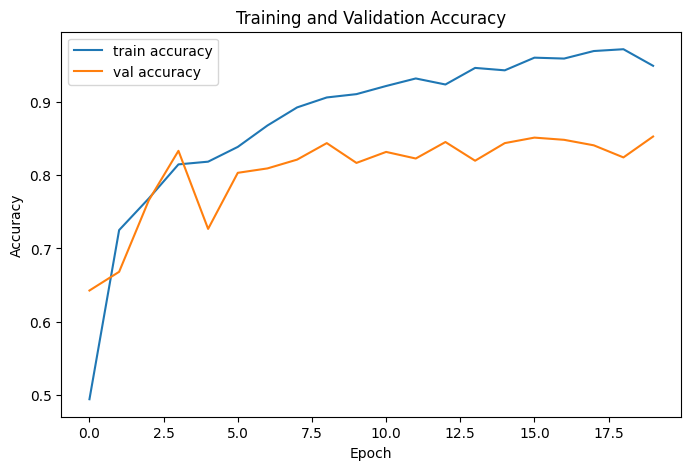

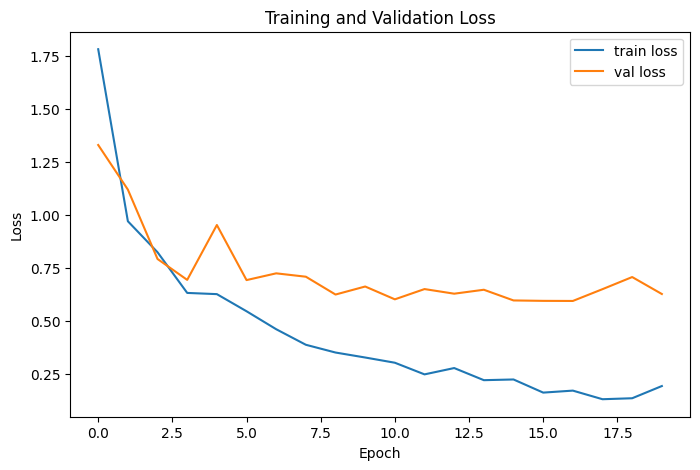

In [13]:
plot_history(history)